# Fake News Detection using NLP

This notebook builds and compares several models for fake news detection:

1. Logistic Regression  
2. Naive Bayes  
3. LSTM  
4. GRU  
5. BERT  

The goal is to classify news articles as **Fake** or **Real** using NLP techniques.


In [ ]:
# ==========================================
# Fake News Detection NLP Project

#Automatically classify news articles as Fake News or Real News using NLP, Machine Learning, Deep Learning, and Transformer models.

# ==========================================
#Requirements:

#pip install tensorflow
#pip install transformers
#pip install nltk
#pip install tf-keras

#Run cells in order:
#1→2→3...
# ==========================================
# Import Required Libraries
# ==========================================

# Fix TensorFlow/Keras compatibility with Transformers in Colab
!pip install tf-keras -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and text preprocessing libraries
import nltk
import re
import string

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# NLTK preprocessing tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Libraries for reproducibility
import random

# Set random seeds to make the results more stable
random.seed(42)
np.random.seed(42)

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# ==========================================
# Load Fake and Real News Datasets
# ==========================================

# Load fake news dataset
fake = pd.read_csv("Fake.csv")

# Load real news dataset
true = pd.read_csv("True.csv")

# Display dataset shapes to understand the dataset size
print("Fake News Shape:", fake.shape)
print("Real News Shape:", true.shape)


Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [3]:
# ==========================================
# Add Labels to the Datasets
# ==========================================

# Assign label 0 to fake news
fake["label"] = 0

# Assign label 1 to real news
true["label"] = 1

# Display first rows from both datasets
print("Fake News Sample")
display(fake.head())

print("Real News Sample")
display(true.head())


Fake News Sample


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Real News Sample


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [4]:
# ==========================================
# Merge and Shuffle the Dataset
# ==========================================

# Combine fake and real datasets into one dataframe
data = pd.concat([fake, true], axis=0)

# Fill missing title and text values to avoid errors during preprocessing
data["title"] = data["title"].fillna("").astype(str)
data["text"] = data["text"].fillna("").astype(str)

# Keep the original full text for BERT
# BERT works better with natural sentences, so we do not apply stemming or lemmatization to this column
data["bert_text"] = data["title"] + " " + data["text"]

# Shuffle the dataset with random_state=42 so the result is reproducible
data = data.sample(frac=1, random_state=42)

# Reset index after shuffling
data.reset_index(drop=True, inplace=True)

# Display dataset information
print("Dataset Shape:", data.shape)
display(data.head())


Dataset Shape: (44898, 6)


,title,text,subject,date,label,bert_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...


In [5]:
# ==========================================
# Check Missing Values
# ==========================================

# Check if the dataset has any missing values after cleaning
print(data.isnull().sum())


title        0
text         0
subject      0
date         0
label        0
bert_text    0
dtype: int64


In [ ]:
# ==========================================
# Create NLP Preprocessing Tools
# ==========================================

# Store English stopwords such as: the, is, and, in
stop_words = set(stopwords.words('english'))

# Create stemming object to reduce words to their---- root form----
stemmer = PorterStemmer()

# Create lemmatization object to reduce words to their dictionary form
lemmatizer = WordNetLemmatizer()


In [7]:
# ==========================================
# Text Preprocessing Function
# ==========================================

def preprocess_text(text):
    """
    This function cleans the text before using it in TF-IDF, LSTM, and GRU.
    Steps:
    1. Convert text to lowercase.
    2. Remove punctuation.
    3. Remove numbers.
    4. Tokenize the text.
    5. Remove stopwords.
    6. Apply stemming and lemmatization.
    """

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation marks
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # Remove words that contain numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Split text into individual words
    words = word_tokenize(text)

    processed_words = []

    for word in words:
        # Remove stopwords
        if word not in stop_words:
            # Apply stemming
            word = stemmer.stem(word)

            # Apply lemmatization
            word = lemmatizer.lemmatize(word)

            # Add cleaned word to the final list
            processed_words.append(word)

    # Join cleaned words back into one sentence
    return " ".join(processed_words)


In [8]:
# ==========================================
# Apply Text Preprocessing
# ==========================================

# Apply preprocessing only to the text column used by traditional ML and RNN models
data["clean_text"] = data["text"].apply(preprocess_text)

# Display processed text samples
print("Processed Text Samples")
display(data["clean_text"].head())


Processed Text Samples


,clean_text
0,centuri wire say ben stein reput professor pep...
1,washington reuter u presid donald trump remov ...
2,reuter puerto rico governor ricardo rossello s...
3,monday donald trump embarrass countri accident...
4,glasgow scotland reuter u presidenti candid go...


In [9]:
# ==========================================
# Define Features and Labels
# ==========================================

# X contains cleaned text for Logistic Regression, Naive Bayes, LSTM, and GRU
X = data["clean_text"]

# X_bert contains original text for BERT
X_bert = data["bert_text"]

# y contains the target labels: 0 = Fake, 1 = Real
y = data["label"]

# Display sample data
print("Clean Text Sample")
print(X.head())

print("Labels Sample")
print(y.head())


Clean Text Sample
0    centuri wire say ben stein reput professor pep...
1    washington reuter u presid donald trump remov ...
2    reuter puerto rico governor ricardo rossello s...
3    monday donald trump embarrass countri accident...
4    glasgow scotland reuter u presidenti candid go...
Name: clean_text, dtype: object
Labels Sample
0    0
1    1
2    1
3    0
4    1
Name: label, dtype: int64


In [10]:
# ==========================================
# Split Dataset into Training and Testing Sets
# ==========================================

# Split the dataset into training and testing sets
# stratify=y keeps the same percentage of Fake and Real news in both sets
X_train, X_test, X_train_bert, X_test_bert, y_train, y_test = train_test_split(
    X,
    X_bert,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Display dataset sizes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

# Check label distribution after stratified split
print("\nTraining Label Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Label Distribution:")
print(y_test.value_counts(normalize=True))


Training Data Shape: (33673,)
Testing Data Shape : (11225,)

Training Label Distribution:
label
0    0.522971
1    0.477029
Name: proportion, dtype: float64

Testing Label Distribution:
label
0    0.523029
1    0.476971
Name: proportion, dtype: float64


In [11]:
# ==========================================
# TF-IDF Feature Representation
# ==========================================

# Create TF-IDF vectorizer
# max_features=5000 keeps the most important 5000 words
# This helps reduce noise and keeps the model efficient
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit TF-IDF only on training data to avoid data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform testing data using the same fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Display TF-IDF matrix shapes
print("X_train_tfidf Shape:", X_train_tfidf.shape)
print("X_test_tfidf Shape :", X_test_tfidf.shape)


X_train_tfidf Shape: (33673, 5000)
X_test_tfidf Shape : (11225, 5000)


In [12]:
# ==========================================
# Helper Function for Model Evaluation
# ==========================================

def evaluate_model(model_name, y_true, y_pred):
    """
    This function calculates and prints the main evaluation metrics.
    It returns accuracy, precision, recall, and F1-score.
    """

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(model_name, "Results")
    print("--------------------------------")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

    return accuracy, precision, recall, f1


def plot_confusion_matrix(y_true, y_pred, title, color):
    """
    This function plots the confusion matrix for any model.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


In [13]:
# ==========================================
# Baseline Model 1: Logistic Regression
# ==========================================

# Create Logistic Regression model
# This is a strong baseline model for text classification
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using TF-IDF features
lr_model.fit(X_train_tfidf, y_train)

# Predict labels for testing data
lr_predictions = lr_model.predict(X_test_tfidf)

# Evaluate the model
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)


Logistic Regression Results
--------------------------------
Accuracy : 0.9864587973273942
Precision: 0.9814883376527213
Recall   : 0.9902876354127755
F1-Score : 0.9858683525474154

Classification Report
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      5871
        Real       0.98      0.99      0.99      5354

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



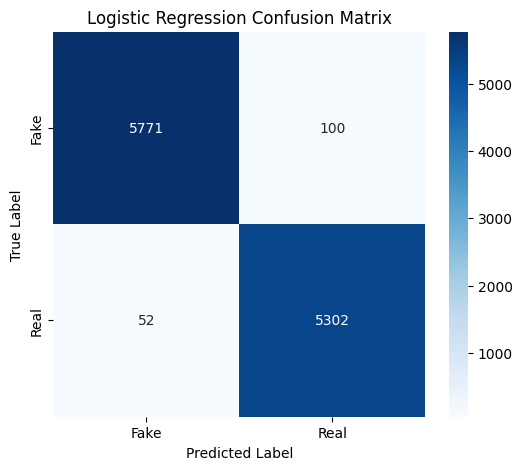

In [14]:
# ==========================================
# Confusion Matrix - Logistic Regression
# ==========================================

plot_confusion_matrix(
    y_test,
    lr_predictions,
    "Logistic Regression Confusion Matrix",
    "Blues"
)


In [15]:
# ==========================================
# Baseline Model 2: Naive Bayes
# ==========================================

# Create Naive Bayes model
# This model is simple and commonly used for text classification tasks
nb_model = MultinomialNB()

# Train the model using TF-IDF features
nb_model.fit(X_train_tfidf, y_train)

# Predict labels for testing data
nb_predictions = nb_model.predict(X_test_tfidf)

# Evaluate the model
nb_accuracy, nb_precision, nb_recall, nb_f1 = evaluate_model(
    "Naive Bayes",
    y_test,
    nb_predictions
)


Naive Bayes Results
--------------------------------
Accuracy : 0.9265924276169265
Precision: 0.9289772727272727
Recall   : 0.9161374673141577
F1-Score : 0.922512695128832

Classification Report
              precision    recall  f1-score   support

        Fake       0.92      0.94      0.93      5871
        Real       0.93      0.92      0.92      5354

    accuracy                           0.93     11225
   macro avg       0.93      0.93      0.93     11225
weighted avg       0.93      0.93      0.93     11225



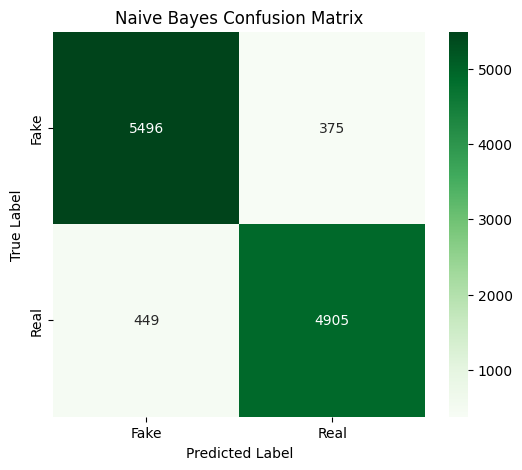

In [16]:
# ==========================================
# Confusion Matrix - Naive Bayes
# ==========================================

plot_confusion_matrix(
    y_test,
    nb_predictions,
    "Naive Bayes Confusion Matrix",
    "Greens"
)


In [17]:
# ==========================================
# Import Deep Learning Libraries
# ==========================================

import tensorflow as tf

# Set TensorFlow seed for more stable deep learning results
tf.random.set_seed(42)

# Text tokenization and padding tools
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Keras model and layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout
)


In [18]:
# ==========================================
# Tokenize Text for LSTM and GRU
# ==========================================

# Create tokenizer that keeps the most frequent 5000 words
# oov_token is used for unseen words in testing data
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")

# Fit tokenizer only on training data to avoid data leakage
tokenizer.fit_on_texts(X_train)

# Convert text into sequences of word indexes
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Display one example sequence
print("Sample Sequence:")
print(X_train_seq[0][:30])


Sample Sequence:
[1, 21, 559, 1, 978, 13, 1116, 164, 654, 4567, 132, 4568, 3669, 7, 443, 70, 205, 326, 640, 2, 97, 264, 182, 73, 443, 560, 416, 583, 420, 149]


In [19]:
# ==========================================
# Pad Sequences for LSTM and GRU
# ==========================================

# Define maximum sequence length
# Shorter texts will be padded, and longer texts will be truncated
max_length = 200

# Pad training sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Pad testing sequences
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Display padded sequence shapes
print("X_train_pad Shape:", X_train_pad.shape)
print("X_test_pad Shape :", X_test_pad.shape)


X_train_pad Shape: (33673, 200)
X_test_pad Shape : (11225, 200)


In [20]:
# ==========================================
# Build LSTM Model
# ==========================================

# Create Sequential model
lstm_model = Sequential()

# Input layer fixes the model shape and makes the summary clear
lstm_model.add(Input(shape=(max_length,)))

# Embedding layer converts word indexes into dense vectors
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128
    )
)

# LSTM layer learns sequence patterns in the text
lstm_model.add(LSTM(64))

# Dropout helps reduce overfitting
lstm_model.add(Dropout(0.5))

# Output layer for binary classification
# Sigmoid gives probability between 0 and 1
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile the model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture and number of parameters
lstm_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          640000    
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 689473 (2.63 MB)
Trainable params: 689473 (2.63 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [21]:
# ==========================================
# Train LSTM Model
# ==========================================

# Train the model with validation split to monitor overfitting
# Only 3 epochs are used to keep training reasonable and reduce overfitting risk
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/3
421/421 [==============================] - 42s 89ms/step - loss: 0.3080 - accuracy: 0.8877 - val_loss: 0.1425 - val_accuracy: 0.9651
Epoch 2/3
421/421 [==============================] - 14s 34ms/step - loss: 0.1820 - accuracy: 0.9535 - val_loss: 0.2928 - val_accuracy: 0.9268
Epoch 3/3
421/421 [==============================] - 9s 21ms/step - loss: 0.2143 - accuracy: 0.9236 - val_loss: 0.2066 - val_accuracy: 0.9298


In [22]:
# ==========================================
# Evaluate LSTM Model
# ==========================================

# Predict probabilities on testing data
lstm_probabilities = lstm_model.predict(X_test_pad)

# Convert probabilities into binary labels
lstm_predictions = (lstm_probabilities > 0.5).astype(int).ravel()

# Evaluate the model
lstm_accuracy, lstm_precision, lstm_recall, lstm_f1 = evaluate_model(
    "LSTM",
    y_test,
    lstm_predictions
)


351/351 [==============================] - 3s 6ms/step
LSTM Results
--------------------------------
Accuracy : 0.9241870824053452
Precision: 0.865681338314114
Recall   : 0.9955173701905118
F1-Score : 0.9260707149682912

Classification Report
              precision    recall  f1-score   support

        Fake       1.00      0.86      0.92      5871
        Real       0.87      1.00      0.93      5354

    accuracy                           0.92     11225
   macro avg       0.93      0.93      0.92     11225
weighted avg       0.93      0.92      0.92     11225



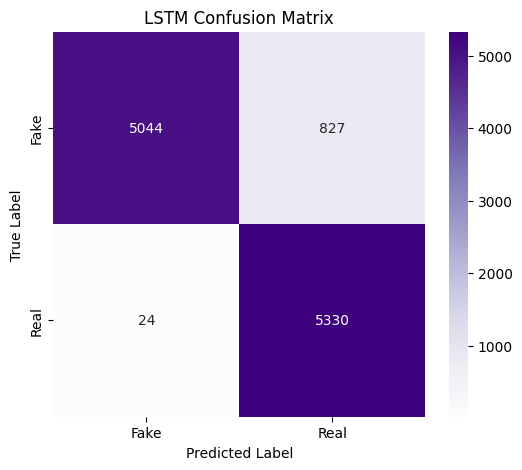

In [23]:
# ==========================================
# Confusion Matrix - LSTM
# ==========================================

plot_confusion_matrix(
    y_test,
    lstm_predictions,
    "LSTM Confusion Matrix",
    "Purples"
)


In [24]:
# ==========================================
# Advanced Model 2: GRU
# ==========================================

# Create Sequential model
gru_model = Sequential()

# Input layer fixes the model shape and makes the summary clear
gru_model.add(Input(shape=(max_length,)))

# Embedding layer converts word indexes into dense vectors
gru_model.add(
    Embedding(
        input_dim=5000,
        output_dim=128
    )
)

# GRU layer learns sequence patterns and is usually faster than LSTM
gru_model.add(GRU(64))

# Dropout helps reduce overfitting
gru_model.add(Dropout(0.5))

# Output layer for binary classification
gru_model.add(Dense(1, activation='sigmoid'))

# Compile the model
gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model architecture and number of parameters
gru_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 200, 128)          640000    
                                                                 
 gru (GRU)                   (None, 64)                37248     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 677313 (2.58 MB)
Trainable params: 677313 (2.58 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
# ==========================================
# Train GRU Model
# ==========================================

# Train the GRU model with validation split to monitor overfitting
gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)


Epoch 1/3
421/421 [==============================] - 39s 87ms/step - loss: 0.2756 - accuracy: 0.8921 - val_loss: 0.1322 - val_accuracy: 0.9666
Epoch 2/3
421/421 [==============================] - 14s 33ms/step - loss: 0.1574 - accuracy: 0.9604 - val_loss: 0.1267 - val_accuracy: 0.9644
Epoch 3/3
421/421 [==============================] - 10s 23ms/step - loss: 0.0294 - accuracy: 0.9941 - val_loss: 0.0064 - val_accuracy: 0.9990


In [26]:
# ==========================================
# Evaluate GRU Model
# ==========================================

# Predict probabilities on testing data
gru_probabilities = gru_model.predict(X_test_pad)

# Convert probabilities into binary labels
gru_predictions = (gru_probabilities > 0.5).astype(int).ravel()

# Evaluate the model
gru_accuracy, gru_precision, gru_recall, gru_f1 = evaluate_model(
    "GRU",
    y_test,
    gru_predictions
)


351/351 [==============================] - 2s 4ms/step
GRU Results
--------------------------------
Accuracy : 0.9983964365256125
Precision: 0.9981329350261389
Recall   : 0.9985057900635039
F1-Score : 0.9983193277310924

Classification Report
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      5871
        Real       1.00      1.00      1.00      5354

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225



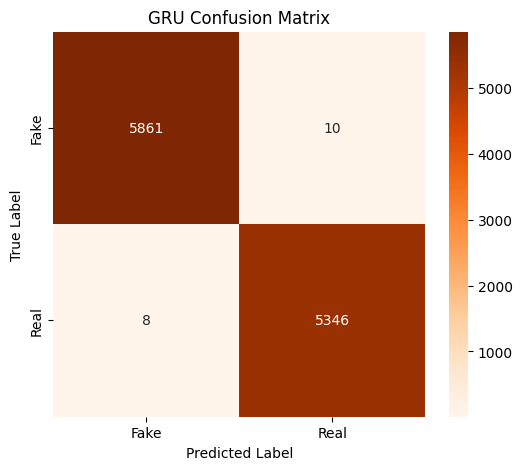

In [27]:
# ==========================================
# Confusion Matrix - GRU
# ==========================================

plot_confusion_matrix(
    y_test,
    gru_predictions,
    "GRU Confusion Matrix",
    "Oranges"
)


In [28]:
# ==========================================
# Install Transformers Library for BERT
# ==========================================

# Run this cell if transformers is not installed in your environment
# BERT is heavier than the other models, so it is better to run this part on GPU
!pip install transformers==4.41.2 -q


In [29]:
# ==========================================
# Import BERT Libraries
# ==========================================

# Hugging Face Transformers library is used to load pretrained BERT
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification


In [30]:
# ==========================================
# Prepare Data for BERT Model
# ==========================================

# BERT uses original sentences, not the cleaned/stemmed text
# Create a validation set from the training data for monitoring overfitting
X_bert_train, X_bert_val, y_bert_train, y_bert_val = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Convert labels to numpy arrays for TensorFlow datasets
y_bert_train = np.array(y_bert_train)
y_bert_val = np.array(y_bert_val)
y_bert_test = np.array(y_test)

# Display BERT data sizes
print("BERT Training Data Shape  :", X_bert_train.shape)
print("BERT Validation Data Shape:", X_bert_val.shape)
print("BERT Testing Data Shape   :", X_test_bert.shape)


BERT Training Data Shape  : (26938,)
BERT Validation Data Shape: (6735,)
BERT Testing Data Shape   : (11225,)


In [31]:
# ==========================================
# Tokenize Text for BERT
# ==========================================

# Define pretrained BERT model name
bert_model_name = "bert-base-uncased"

# Create BERT tokenizer
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

# Define maximum sequence length
# 128 keeps training faster while still keeping enough text context
bert_max_length = 128

# Tokenize training data
bert_train_encodings = bert_tokenizer(
    X_bert_train.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=bert_max_length,
    return_tensors="tf"
)

# Tokenize validation data
bert_val_encodings = bert_tokenizer(
    X_bert_val.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=bert_max_length,
    return_tensors="tf"
)

# Tokenize testing data
bert_test_encodings = bert_tokenizer(
    X_test_bert.astype(str).tolist(),
    truncation=True,
    padding=True,
    max_length=bert_max_length,
    return_tensors="tf"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [32]:
# ==========================================
# Create TensorFlow Datasets for BERT
# ==========================================

# Define batch size
# If GPU memory is low, reduce this value to 8
bert_batch_size = 16

# Create training dataset
# shuffle is used only for training data
bert_train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(bert_train_encodings),
    y_bert_train
)).shuffle(1000, seed=42).batch(bert_batch_size)

# Create validation dataset
bert_val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(bert_val_encodings),
    y_bert_val
)).batch(bert_batch_size)

# Create testing dataset
bert_test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(bert_test_encodings),
    y_bert_test
)).batch(bert_batch_size)


In [33]:
# ==========================================
# Build BERT Model
# ==========================================

# Load pretrained BERT model for binary classification
# num_labels=2 because the classes are Fake and Real
bert_model = TFAutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2
)

# Compile BERT with a small learning rate
# A small learning rate is common for fine-tuning pretrained transformer models
bert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Display BERT model summary
bert_model.summary()


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_39 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
# ==========================================
# Train BERT Model
# ==========================================

# Train BERT for only 2 epochs to reduce overfitting risk
# This part is better to run on Kaggle or Colab GPU
bert_history = bert_model.fit(
    bert_train_dataset,
    validation_data=bert_val_dataset,
    epochs=2
)


Epoch 1/2
1684/1684 [==============================] - 933s 525ms/step - loss: 0.0140 - accuracy: 0.9970 - val_loss: 0.0071 - val_accuracy: 0.9985
Epoch 2/2
1684/1684 [==============================] - 882s 524ms/step - loss: 0.0029 - accuracy: 0.9994 - val_loss: 0.0045 - val_accuracy: 0.9993


In [35]:
# ==========================================
# Evaluate BERT Model
# ==========================================

# Predict logits using testing data
bert_outputs = bert_model.predict(bert_test_dataset)

# Convert logits into class labels
bert_predictions = np.argmax(bert_outputs.logits, axis=1)

# Evaluate the model
bert_accuracy, bert_precision, bert_recall, bert_f1 = evaluate_model(
    "BERT",
    y_test,
    bert_predictions
)


702/702 [==============================] - 117s 163ms/step
BERT Results
--------------------------------
Accuracy : 0.9996436525612472
Precision: 1.0
Recall   : 0.999252895031752
F1-Score : 0.999626307922272

Classification Report
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      5871
        Real       1.00      1.00      1.00      5354

    accuracy                           1.00     11225
   macro avg       1.00      1.00      1.00     11225
weighted avg       1.00      1.00      1.00     11225



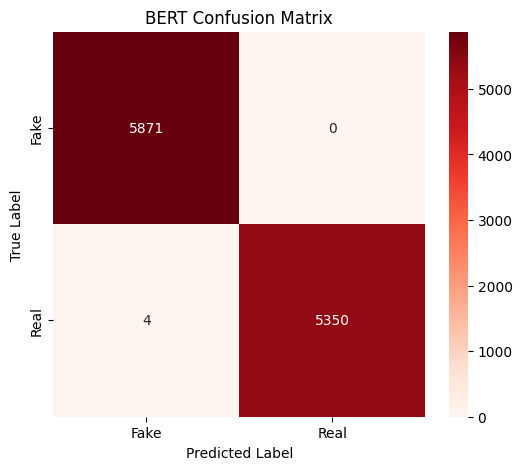

In [36]:
# ==========================================
# Confusion Matrix - BERT
# ==========================================

plot_confusion_matrix(
    y_test,
    bert_predictions,
    "BERT Confusion Matrix",
    "Reds"
)


In [37]:
# ==========================================
# Overfitting Check for Deep Learning Models
# ==========================================

# This function compares training and validation results
# Small gaps between training and validation accuracy usually mean there is no strong overfitting

def check_overfitting(history_object, model_name):
    """
    Print final training and validation metrics for a deep learning model.
    """

    train_acc = history_object.history["accuracy"][-1]
    val_acc = history_object.history["val_accuracy"][-1]
    train_loss = history_object.history["loss"][-1]
    val_loss = history_object.history["val_loss"][-1]
    accuracy_gap = abs(train_acc - val_acc)

    print(model_name)
    print("----------------------------")
    print("Training Accuracy  :", train_acc)
    print("Validation Accuracy:", val_acc)
    print("Training Loss      :", train_loss)
    print("Validation Loss    :", val_loss)
    print("Accuracy Gap       :", accuracy_gap)

    # Simple interpretation of overfitting
    if accuracy_gap < 0.03 and val_loss <= train_loss + 0.10:
        print("Conclusion         : No strong overfitting")
    else:
        print("Conclusion         : Possible overfitting, check validation loss")

    print()

# Check overfitting for each deep learning model
check_overfitting(lstm_history, "LSTM")
check_overfitting(gru_history, "GRU")
check_overfitting(bert_history, "BERT")


LSTM
----------------------------
Training Accuracy  : 0.9235652089118958
Validation Accuracy: 0.9297698736190796
Training Loss      : 0.21429577469825745
Validation Loss    : 0.2066383808851242
Accuracy Gap       : 0.006204664707183838
Conclusion         : No strong overfitting

GRU
----------------------------
Training Accuracy  : 0.9940604567527771
Validation Accuracy: 0.9989606738090515
Training Loss      : 0.029380187392234802
Validation Loss    : 0.006350687704980373
Accuracy Gap       : 0.004900217056274414
Conclusion         : No strong overfitting

BERT
----------------------------
Training Accuracy  : 0.9994060397148132
Validation Accuracy: 0.9992576241493225
Training Loss      : 0.002944434527307749
Validation Loss    : 0.004495333414524794
Accuracy Gap       : 0.00014841556549072266
Conclusion         : No strong overfitting



In [38]:
# ==========================================
# Model Comparison Table
# ==========================================

# Create comparison dataframe for all models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LSTM",
        "GRU",
        "BERT"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        lstm_accuracy,
        gru_accuracy,
        bert_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision,
        lstm_precision,
        gru_precision,
        bert_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall,
        lstm_recall,
        gru_recall,
        bert_recall
    ],
    "F1-Score": [
        lr_f1,
        nb_f1,
        lstm_f1,
        gru_f1,
        bert_f1
    ]
})

# Sort models based on F1-score because F1 balances precision and recall
results = results.sort_values(by="F1-Score", ascending=False)

# Display final comparison table
display(results)


,Model,Accuracy,Precision,Recall,F1-Score
4,BERT,0.999644,1.000000,0.999253,0.999626
3,GRU,0.998396,0.998133,0.998506,0.998319
0,Logistic Regression,0.986459,0.981488,0.990288,0.985868
2,LSTM,0.924187,0.865681,0.995517,0.926071
1,Naive Bayes,0.926592,0.928977,0.916137,0.922513


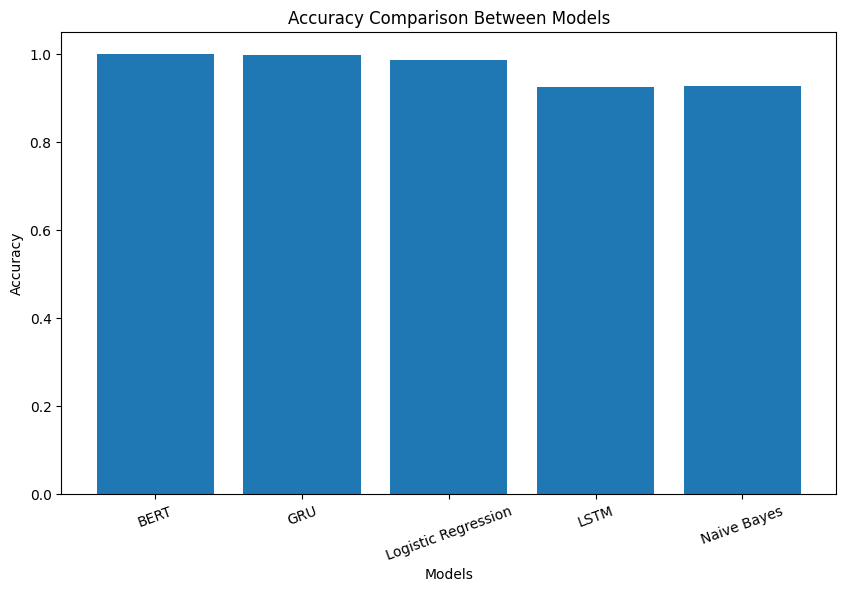

In [39]:
# ==========================================
# Visualize Accuracy Comparison
# ==========================================

# Set figure size
plt.figure(figsize=(10, 6))

# Plot accuracy comparison
plt.bar(results["Model"], results["Accuracy"])

# Add labels and title
plt.title("Accuracy Comparison Between Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

# Show plot
plt.show()


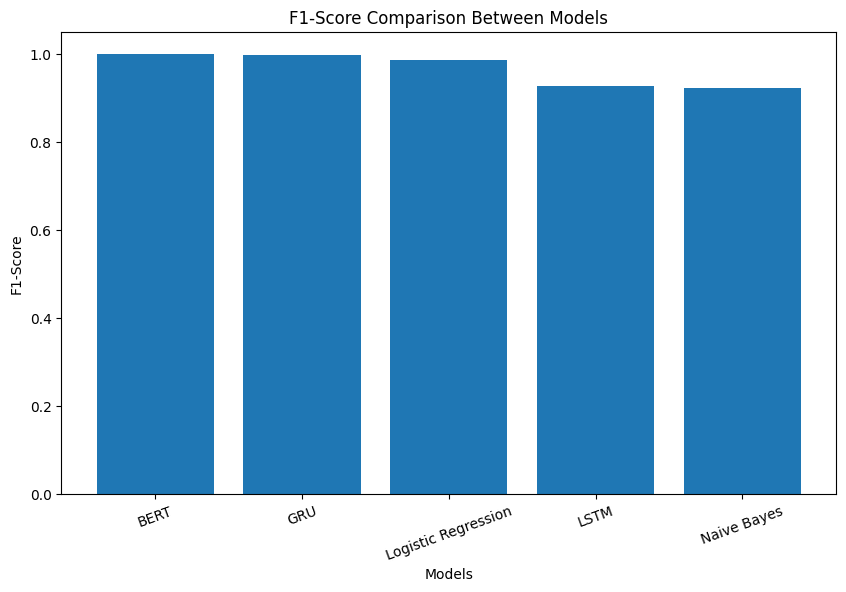

In [40]:
# ==========================================
# Visualize F1-Score Comparison
# ==========================================

# Set figure size
plt.figure(figsize=(10, 6))

# Plot F1-score comparison
plt.bar(results["Model"], results["F1-Score"])

# Add labels and title
plt.title("F1-Score Comparison Between Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=20)

# Show plot
plt.show()


In [41]:
# ==========================================
# Final Best Model Selection
# ==========================================

# Select the best model based on F1-score
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Model Based on F1-Score")
print("--------------------------------")
print("Model    :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall   :", best_model["Recall"])
print("F1-Score :", best_model["F1-Score"])


Best Model Based on F1-Score
--------------------------------
Model    : BERT
Accuracy : 0.9996436525612472
Precision: 1.0
Recall   : 0.999252895031752
F1-Score : 0.999626307922272


## Final Notes

- Logistic Regression is used as a strong baseline model.  
- Naive Bayes is included as a simple probabilistic NLP model.  
- LSTM and GRU are deep learning sequence models.  
- BERT is added as a transformer-based model for modern NLP comparison.  
- The best model is selected using F1-score because it balances precision and recall.
